In [ ]:
#Importing libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.style
import seaborn as sns


from datetime import datetime
from scipy.optimize import curve_fit
from math import sqrt
import random
import warnings
warnings.filterwarnings('ignore')

# formatting for decimal places
pd.set_option("display.float_format", "{:.2f}".format)

In [ ]:
# setting seed for model reproducibility
import os
seed_value = 42
os.environ['PYTHONHASHSEED'] = str(seed_value)
random.seed(seed_value)
np.random.seed(seed_value)

In [ ]:
#import dataset and make the ReportDate column as the index column
train_prod = pd.read_csv('/content/train_prod.csv')
test_prod = pd.read_csv('/content/test_prod.csv')
print(train_prod.info())
print(test_prod.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 684415 entries, 0 to 684414
Data columns (total 22 columns):
 #   Column      Non-Null Count   Dtype  
---  ------      --------------   -----  
 0   Unnamed: 0  684415 non-null  int64  
 1   ReportDate  684415 non-null  object 
 2   API_WELLNO  684415 non-null  float64
 3   FileNo      684415 non-null  float64
 4   Company     684415 non-null  object 
 5   WellName    684415 non-null  object 
 6   Quarter     684415 non-null  object 
 7   Section     684415 non-null  float64
 8   Township    684415 non-null  float64
 9   Range       684415 non-null  float64
 10  County      684415 non-null  object 
 11  FieldName   684415 non-null  object 
 12  Pool        684415 non-null  object 
 13  Oil         678599 non-null  float64
 14  Wtr         678599 non-null  float64
 15  Days        678599 non-null  float64
 16  Runs        684415 non-null  float64
 17  Gas         678599 non-null  float64
 18  GasSold     684415 non-null  float64
 19  Fl

In [ ]:
train_prod.head()

,Unnamed: 0,ReportDate,API_WELLNO,FileNo,Company,WellName,Quarter,Section,Township,Range,...,Pool,Oil,Wtr,Days,Runs,Gas,GasSold,Flared,Lat,Long
0,0,2015-05-01,33053043310000.00,23615.00,MUREX PETROLEUM CORPORATION,AMBER ELIZABETH 36-25H,SESW,36.00,151.00,101.00,...,BAKKEN,1525.00,1335.00,29.00,1686.00,1739.00,1519.00,0.00,47.85,-103.55
1,1,2015-05-01,33053038990000.00,22021.00,STATOIL OIL & GAS LP,BILL 14-23 2TFH,SWSW,11.00,151.00,101.00,...,BAKKEN,1410.00,5805.00,31.00,1370.00,1721.00,1720.00,1.00,47.91,-103.58
2,2,2015-05-01,33053048330000.00,25091.00,STATOIL OIL & GAS LP,BILL 14-23 3H,NWNE,14.00,151.00,101.00,...,BAKKEN,5035.00,12773.00,28.00,5087.00,3754.00,3249.00,505.00,47.90,-103.57
3,3,2015-05-01,33053050010000.00,25645.00,STATOIL OIL & GAS LP,BILL 14-23 4TFH,NWNE,14.00,151.00,101.00,...,BAKKEN,2419.00,17671.00,31.00,2287.00,232.00,201.00,31.00,47.90,-103.57
4,4,2015-05-01,33053048340000.00,25092.00,STATOIL OIL & GAS LP,BILL 14-23 5TFH,NWNE,14.00,151.00,101.00,...,BAKKEN,771.00,17718.00,31.00,729.00,53.00,46.00,7.00,47.90,-103.57


In [ ]:
#converting the ReportDate to datetime in the 2 dataset
train_prod["ReportDate"] = pd.to_datetime(train_prod["ReportDate"])
test_prod["ReportDate"] = pd.to_datetime(test_prod["ReportDate"])

In [ ]:
#A function for pre-processing of the datasets

def pre_processing(df, column):
    #Drop the Unnamed: 0 column
    df.drop("Unnamed: 0", axis=1, inplace=True)

    #Print out the list of columns
    print(df.columns)

     #Check the number of missing values
    null = df.isnull().sum()
    print(null)
    #print out the columns with missing values as a list
    df_null = df.columns[df.isnull().any()].tolist()
    print(df_null)

    # descriptive statistics
    df.describe().T
    df.head(5)
    df.nunique()
    df.dtypes
    df.shape
    # filtering
    #df.dropna(inplace=True)
    # drop rows where oil rate is 0
    df = df[(df[column].notnull()) & (df[column] > 0)]
    return df

In [ ]:
#Pre-processing and EDA

train_prod = pre_processing(train_prod, 'Oil')
test_prod = pre_processing(test_prod, 'Oil')

Index(['ReportDate', 'API_WELLNO', 'FileNo', 'Company', 'WellName', 'Quarter',
       'Section', 'Township', 'Range', 'County', 'FieldName', 'Pool', 'Oil',
       'Wtr', 'Days', 'Runs', 'Gas', 'GasSold', 'Flared', 'Lat', 'Long'],
      dtype='object')
ReportDate       0
API_WELLNO       0
FileNo           0
Company          0
WellName         0
Quarter          0
Section          0
Township         0
Range            0
County           0
FieldName        0
Pool             0
Oil           5816
Wtr           5816
Days          5816
Runs             0
Gas           5816
GasSold          0
Flared        5816
Lat              0
Long             0
dtype: int64
['Oil', 'Wtr', 'Days', 'Gas', 'Flared']
Index(['ReportDate', 'API_WELLNO', 'FileNo', 'Company', 'WellName', 'Quarter',
       'Section', 'Township', 'Range', 'County', 'FieldName', 'Pool', 'Oil',
       'Wtr', 'Days', 'Runs', 'Gas', 'GasSold', 'Flared', 'Lat', 'Long'],
      dtype='object')
ReportDate       0
API_WELLNO       0
FileNo

In [ ]:
#Info
print(train_prod.info())
print(test_prod.info())

<class 'pandas.core.frame.DataFrame'>
Index: 588819 entries, 0 to 684414
Data columns (total 21 columns):
 #   Column      Non-Null Count   Dtype         
---  ------      --------------   -----         
 0   ReportDate  588819 non-null  datetime64[ns]
 1   API_WELLNO  588819 non-null  float64       
 2   FileNo      588819 non-null  float64       
 3   Company     588819 non-null  object        
 4   WellName    588819 non-null  object        
 5   Quarter     588819 non-null  object        
 6   Section     588819 non-null  float64       
 7   Township    588819 non-null  float64       
 8   Range       588819 non-null  float64       
 9   County      588819 non-null  object        
 10  FieldName   588819 non-null  object        
 11  Pool        588819 non-null  object        
 12  Oil         588819 non-null  float64       
 13  Wtr         588819 non-null  float64       
 14  Days        588819 non-null  float64       
 15  Runs        588819 non-null  float64       
 16  Gas    

In [ ]:
#Well Names
print(train_prod.WellName.value_counts().head(10))

WellName
WMPHU  11-9H          88
MILE BUTTE  31-13     88
BEULAH  21-5 SH       88
GRAHAM   43-35SH      88
B. LANGWALD  1        88
MARSHA   34-34SH      88
MILLER  1-13          88
MILLER     1-24       88
H. BORSTAD     3-3    88
MPHU  43-16SH         88
Name: count, dtype: int64


In [ ]:
# find the top 10 wells with highest production (sum)
grouped_data = train_prod.groupby(['API_WELLNO'])['Oil'].sum()
grouped_data = grouped_data.sort_values(ascending=False)
grouped_data = grouped_data.nlargest(10).reset_index()
print(grouped_data)

         API_WELLNO       Oil
0 33025026210000.00 698044.00
1 33053059200000.00 684713.00
2 33053056530000.00 673798.00
3 33053074110000.00 633673.00
4 33053057830000.00 621273.00
5 33053059210000.00 620834.00
6 33053059170000.00 565368.00
7 33053059190000.00 523612.00
8 33025021780000.00 518495.00
9 33055001360000.00 518062.00


In [ ]:
#Selecting API_WELLNO from the grouped_data and converting the pandas series into a numpy for numerical computations
wells = grouped_data['API_WELLNO'].to_numpy()
print(wells)

#selected wells for analysis and vizualization
sel_well = [33053059210000, 33025021780000]
print('API:', sel_well)

[3.30250262e+13 3.30530592e+13 3.30530565e+13 3.30530741e+13
 3.30530578e+13 3.30530592e+13 3.30530592e+13 3.30530592e+13
 3.30250218e+13 3.30550014e+13]
API: [33053059210000, 33025021780000]


In [ ]:
#defining a function that vizualize the rate - time curve (decline curve)

def plot_production_rate(df):
    '''Plot decline curve using production rates'''
    plt.figure(figsize=(12, 8))
    sns.lineplot(x = df['ReportDate'], y = df['oil_rate'], markers=True, dashes=False,
                 label="Oil Production",color='blue', linewidth=1.5)
    plt.title('Oil Rate Vs Time', fontweight='bold', fontsize = 20)
    plt.xlabel('Time', fontweight='bold', fontsize = 15)
    plt.ylabel('Oil Production Rate (bbl/d)', fontweight='bold', fontsize = 15)
    plt.show()

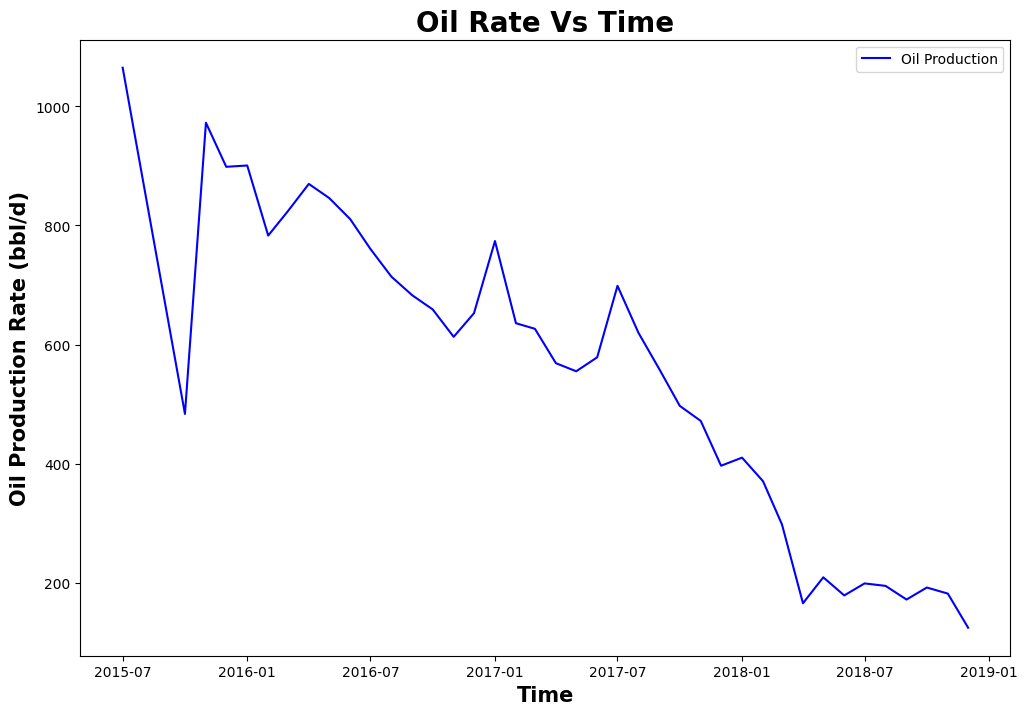

In [ ]:
#selecting the first API and plotting it
df_sel = train_prod[train_prod['API_WELLNO'] == sel_well[0]]
df_sel["oil_rate"] = df_sel["Oil"] / df_sel["Days"]
df_sel['date_delta'] = (df_sel['ReportDate'] - df_sel['ReportDate'].min())/np.timedelta64(1,'D')
plot_production_rate(df_sel)

In [ ]:
def decline_curve(curve_type, q_i):
    if curve_type == "exponential":

        def exponential_decline(T, d):
            return q_i * np.exp(-d * T)
        return exponential_decline

    elif curve_type == "hyperbolic":

        def hyperbolic_decline(T, d_i, b):
            return q_i / np.power((1 + b * d_i * T), 1.0 / b)
        return hyperbolic_decline

    elif curve_type == "harmonic":

        def parabolic_decline(T, d_i):
            return q_i / (1 + d_i * T)
        return parabolic_decline

    else:
        raise "Unknown Decline Curve!"


def L2_norm(Q, Q_obs):
    return np.sum(np.power(np.subtract(Q, Q_obs), 2))

In [ ]:
df_sel = df_sel[['date_delta', 'oil_rate']]
data = df_sel.to_numpy()
# T is number of days of production - cumulative
# q is production rate
T_train, q = data.T #.T transposes the array and unpacks the array
print(T_train)
print(q)

[   0.   92.  123.  153.  184.  215.  244.  275.  305.  336.  366.  397.
  428.  458.  489.  519.  550.  581.  609.  640.  670.  701.  731.  762.
  793.  823.  854.  884.  915.  946.  974. 1005. 1035. 1066. 1096. 1127.
 1158. 1188. 1219. 1249.]
[1065.          483.5         972.6         898.58064516  900.77419355
  783.06896552  823.96774194  869.83333333  846.19354839  810.86666667
  760.61290323  714.03225806  682.6         659.          613.
  652.67741935  773.87096774  635.82142857  626.48387097  568.73333333
  555.12903226  578.58333333  698.67741935  619.67741935  558.26666667
  497.03225806  471.73333333  396.51612903  410.03225806  370.46428571
  297.80645161  165.45833333  209.06451613  178.63333333  198.80645161
  194.67741935  171.73333333  191.90322581  181.7         124.38709677]


In [ ]:
# Assumption - from the graph, we can assume qi to be the max oil production rate
qi = df_sel['oil_rate'].max()
qi

1065.0

In [ ]:
#defining the 3 DCA models using the decline_curve function that was defined earlier
exp_decline = decline_curve("exponential", qi)
hyp_decline = decline_curve("hyperbolic", qi)
har_decline = decline_curve("harmonic", qi)

In [ ]:
#fitting the decline curve models using the curve_fit, optimization method = Trust Region Reflective
popt_exp, pcov_exp = curve_fit(exp_decline, T_train, q, method="trf")
popt_hyp, pcov_hyp = curve_fit(hyp_decline, T_train, q, method="trf")
popt_har, pcov_har = curve_fit(har_decline, T_train, q, method="trf")

In [ ]:
print("Exponential Decline:")
print("Optimal parameters:", popt_exp)
print("Estimated covariance:", pcov_exp)

print("\nHyperbolic Decline:")
print("Optimal parameters:", popt_hyp)
print("Estimated covariance:", pcov_hyp)

print("\nHarmonic Decline:")
print("Optimal parameters:", popt_har)
print("Estimated covariance:", pcov_har)

Exponential Decline:
Optimal parameters: [1.]
Estimated covariance: [[0.]]

Hyperbolic Decline:
Optimal parameters: [ 7.05605926e-04 -1.01246551e+00]
Estimated covariance: [[4.13484547e-09 1.09077626e-05]
 [1.09077626e-05 3.21146403e-02]]

Harmonic Decline:
Optimal parameters: [0.00164211]
Estimated covariance: [[2.42311468e-08]]


In [ ]:
# L2 Norm (Euclidean Norm): It provides a quantitative measure of how well each model fits the observed data

print("L2 Norm of exponential decline: ", L2_norm(exp_decline(T_train, popt_exp[0]), q))
print("L2 Norm of hyperbolic decline decline: ",L2_norm(hyp_decline(T_train, popt_hyp[0], popt_hyp[1]), q))
print("L2 Norm of harmonic decline decline: ", L2_norm(har_decline(T_train, popt_har[0]), q))

L2 Norm of exponential decline:  13873101.93695923
L2 Norm of hyperbolic decline decline:  423150.7014392639
L2 Norm of harmonic decline decline:  811314.1414579843


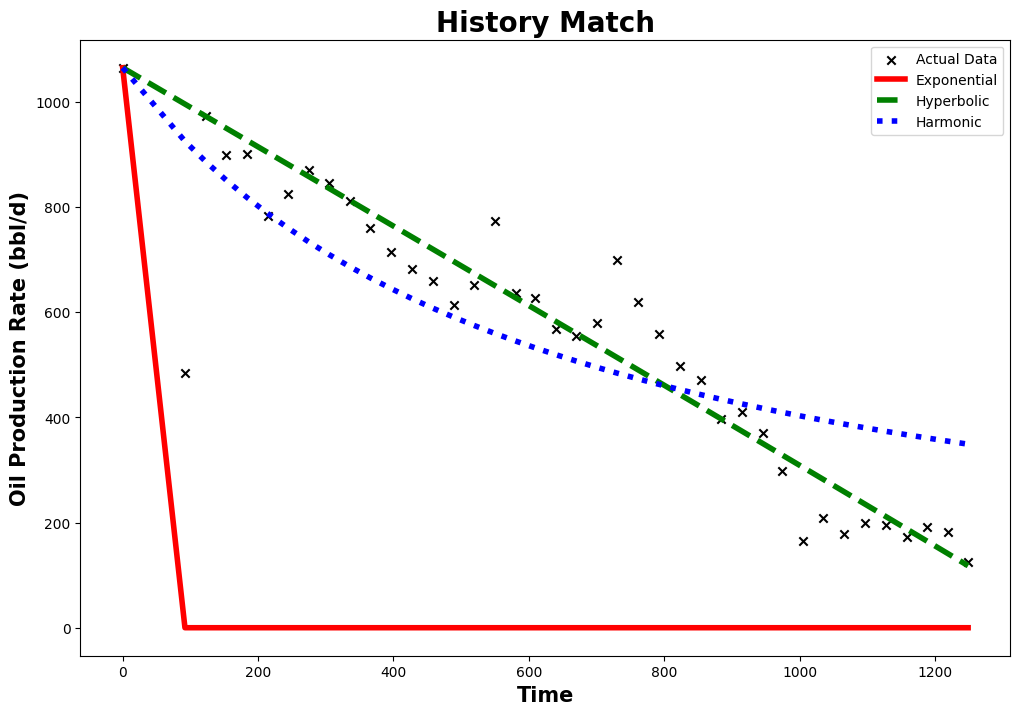

In [ ]:
# Predicting the oil rate using the fitted models
plt.figure(figsize=(12,8))
plt.scatter(T_train, q, color="black", label= "Actual Data", marker="x", alpha=1)
pred_exp = exp_decline(T_train, popt_exp[0])
pred_hyp = hyp_decline(T_train, popt_hyp[0], popt_hyp[1])
pred_har = har_decline(T_train, popt_har[0])
plt.plot(T_train, pred_exp, color="red", label="Exponential", linewidth = 4)
plt.plot(T_train, pred_hyp, color="green", label="Hyperbolic", linestyle="--", linewidth = 4)
plt.plot(T_train, pred_har, color="blue", label="Harmonic", linestyle = ':', linewidth = 4)
plt.title('History Match', fontweight='bold', fontsize = 20)
plt.xlabel('Time', fontweight='bold', fontsize = 15)
plt.ylabel('Oil Production Rate (bbl/d)', fontweight='bold', fontsize = 15)
plt.legend(loc='best')
plt.show()

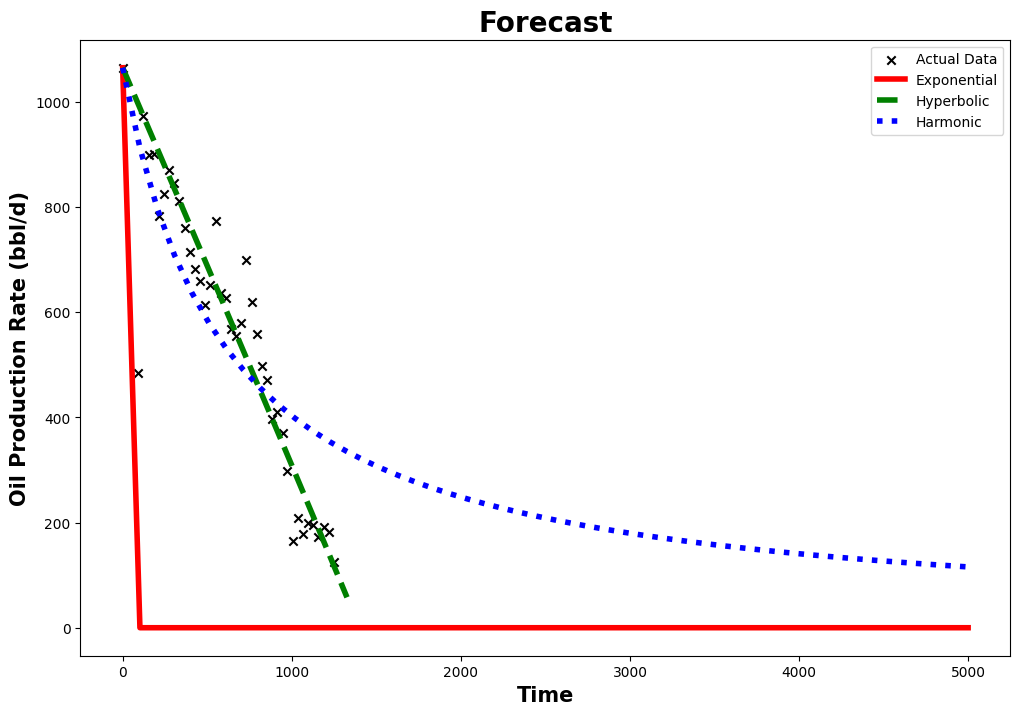

In [ ]:
# Forecasting to 5000 days
max_time_forecast = 5000
T_pred = np.linspace(min(T_train), max_time_forecast)

#Vizualizing the forecasting
plt.figure(figsize=(12,8))
plt.scatter(T_train, q, color="black", label="Actual Data", marker="x", alpha=1)
pred_exp = exp_decline(T_pred, popt_exp[0])
pred_hyp = hyp_decline(T_pred, popt_hyp[0], popt_hyp[1])
pred_har = har_decline(T_pred, popt_har[0])
plt.plot(T_pred, pred_exp, color="red", label="Exponential", linewidth = 4)
plt.plot(T_pred, pred_hyp, color="green", label="Hyperbolic", linestyle="--", linewidth = 4)
plt.plot(T_pred, pred_har, color="blue", label="Harmonic", linestyle = ':', linewidth = 4)
plt.title('Forecast', fontweight='bold', fontsize = 20)
plt.xlabel('Time', fontweight='bold', fontsize = 15)
plt.ylabel('Oil Production Rate (bbl/d)', fontweight='bold', fontsize = 15)
plt.legend(loc='best')
plt.show()

In [ ]:
# validation procedure: Validating the model with the test data

print('API:', sel_well[0])
df_sel_test = test_prod[test_prod['API_WELLNO'] == sel_well[0]]
df_sel_test["oil_rate"] = df_sel_test["Oil"] / df_sel_test["Days"]
df_sel_test['date_delta'] = (df_sel_test['ReportDate'] - df_sel_test['ReportDate'].min())  / np.timedelta64(1,'D')
print(df_sel_test)
df_sel_test = df_sel_test[['date_delta', 'oil_rate']]
data_test = df_sel_test.to_numpy()
# T is number of days of production - cumulative
# q is production rate
T_test, q_test = data_test.T

#T_test = np.concatenate(T_train, T)
print(T_test)
print(q_test)

API: 33053059210000
       ReportDate        API_WELLNO   FileNo                      Company  \
812    2019-01-01 33053059210000.00 28335.00  CONTINENTAL RESOURCES, INC.   
18220  2019-02-01 33053059210000.00 28335.00  CONTINENTAL RESOURCES, INC.   
35679  2019-03-01 33053059210000.00 28335.00  CONTINENTAL RESOURCES, INC.   
53201  2019-04-01 33053059210000.00 28335.00  CONTINENTAL RESOURCES, INC.   
70833  2019-05-01 33053059210000.00 28335.00  CONTINENTAL RESOURCES, INC.   
88576  2019-06-01 33053059210000.00 28335.00  CONTINENTAL RESOURCES, INC.   
106421 2019-07-01 33053059210000.00 28335.00  CONTINENTAL RESOURCES, INC.   
124408 2019-08-01 33053059210000.00 28335.00  CONTINENTAL RESOURCES, INC.   
142501 2019-09-01 33053059210000.00 28335.00  CONTINENTAL RESOURCES, INC.   
160708 2019-10-01 33053059210000.00 28335.00  CONTINENTAL RESOURCES, INC.   
179007 2019-11-01 33053059210000.00 28335.00  CONTINENTAL RESOURCES, INC.   
197414 2019-12-01 33053059210000.00 28335.00  CONTINENTA

In [ ]:
#generates a sequence of date from 'start' with a frequency of Month Start.
#it creates a series of monthly dates
time = pd.date_range(start='6/1/2015', periods= 54, freq='MS')
time

#aligning the time of the train data[-1: last date] with the test data
T_Test2 = T_train[-1] + T_test
len(T_train)

40

In [ ]:
#calculating the predicted prod rates for the train dataset and test dataset(with adjusted time)
pred_hyp =  hyp_decline(T_train, popt_hyp[0], popt_hyp[1])
pred_hyp2 = hyp_decline(T_Test2, popt_hyp[0], popt_hyp[1])
print(pred_hyp)
print(pred_hyp2)

[1065.          995.83611726  972.51760065  949.94465732  926.61225349
  903.27252287  881.43177649  858.07730416  835.46865635  812.0983686
  789.47397741  766.08694207  742.6910021   720.04102061  696.62670055
  673.95833844  650.52436952  627.07987059  605.89480805  582.42912576
  559.70917634  536.21980243  513.47593305  489.96072336  466.43143126
  443.64705405  420.0878479   397.27292521  373.68031311  350.06910591
  328.72580327  305.07548793  282.16630124  258.46904119  235.51038306
  211.75700879  187.97030225  164.9150815   141.04885528  117.90433784]
[117.90433784  93.92814386  72.20633675  48.05896775  24.53978693
          nan          nan          nan          nan          nan
          nan          nan]


In [ ]:
# forecast
#combines the actual production rates for comparison with the forecast.
q_orig = np.append(q, q_test)[:len(time)]

#combines the predicted production rates for the training data (pred_hyp)
#and the test data (pred_hyp2) into a single array called forecast.
forecast = np.concatenate([pred_hyp, pred_hyp2])[:len(time)]

print(len(time))
print(len(q_orig),len(forecast))

54
52 52


In [ ]:
time

DatetimeIndex(['2015-06-01', '2015-07-01', '2015-08-01', '2015-09-01',
               '2015-10-01', '2015-11-01', '2015-12-01', '2016-01-01',
               '2016-02-01', '2016-03-01', '2016-04-01', '2016-05-01',
               '2016-06-01', '2016-07-01', '2016-08-01', '2016-09-01',
               '2016-10-01', '2016-11-01', '2016-12-01', '2017-01-01',
               '2017-02-01', '2017-03-01', '2017-04-01', '2017-05-01',
               '2017-06-01', '2017-07-01', '2017-08-01', '2017-09-01',
               '2017-10-01', '2017-11-01', '2017-12-01', '2018-01-01',
               '2018-02-01', '2018-03-01', '2018-04-01', '2018-05-01',
               '2018-06-01', '2018-07-01', '2018-08-01', '2018-09-01',
               '2018-10-01', '2018-11-01', '2018-12-01', '2019-01-01',
               '2019-02-01', '2019-03-01', '2019-04-01', '2019-05-01',
               '2019-06-01', '2019-07-01', '2019-08-01', '2019-09-01'],
              dtype='datetime64[ns]', freq='MS')

In [ ]:
time= time[:52]

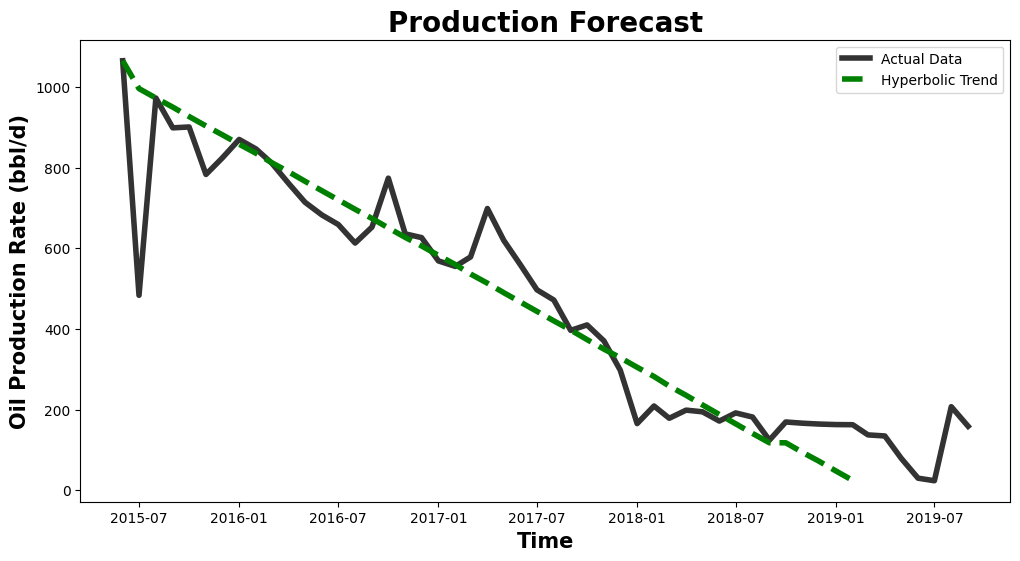

In [ ]:
# hyperbolic forecast - plot
plt.figure(figsize=(12,6))
plt.plot(time, q_orig, color="black", alpha = 0.8, label='Actual Data', linewidth = 4)
plt.plot(time, forecast, color="green", label="Hyperbolic Trend", linewidth = 4, linestyle="--")
plt.title('Production Forecast', fontweight='bold', fontsize = 20)
plt.xlabel('Time', fontweight='bold', fontsize = 15)
plt.ylabel('Oil Production Rate (bbl/d)', fontweight='bold', fontsize = 15)
plt.legend(loc='best')
plt.show()

In [ ]:
forecast_copy= forecast[:45]
q_orig_copy = q_orig[:45]

In [ ]:
forecast_copy[:45]

array([1065.        ,  995.83611726,  972.51760065,  949.94465732,
        926.61225349,  903.27252287,  881.43177649,  858.07730416,
        835.46865635,  812.0983686 ,  789.47397741,  766.08694207,
        742.6910021 ,  720.04102061,  696.62670055,  673.95833844,
        650.52436952,  627.07987059,  605.89480805,  582.42912576,
        559.70917634,  536.21980243,  513.47593305,  489.96072336,
        466.43143126,  443.64705405,  420.0878479 ,  397.27292521,
        373.68031311,  350.06910591,  328.72580327,  305.07548793,
        282.16630124,  258.46904119,  235.51038306,  211.75700879,
        187.97030225,  164.9150815 ,  141.04885528,  117.90433784,
        117.90433784,   93.92814386,   72.20633675,   48.05896775,
         24.53978693])

In [ ]:
from sklearn.metrics import mean_squared_error

rmse = sqrt(mean_squared_error(q_orig_copy, forecast_copy))
print("RMSE - Hyperbolic Method:", rmse)

RMSE - Hyperbolic Method: 102.39635093328177


Well 2

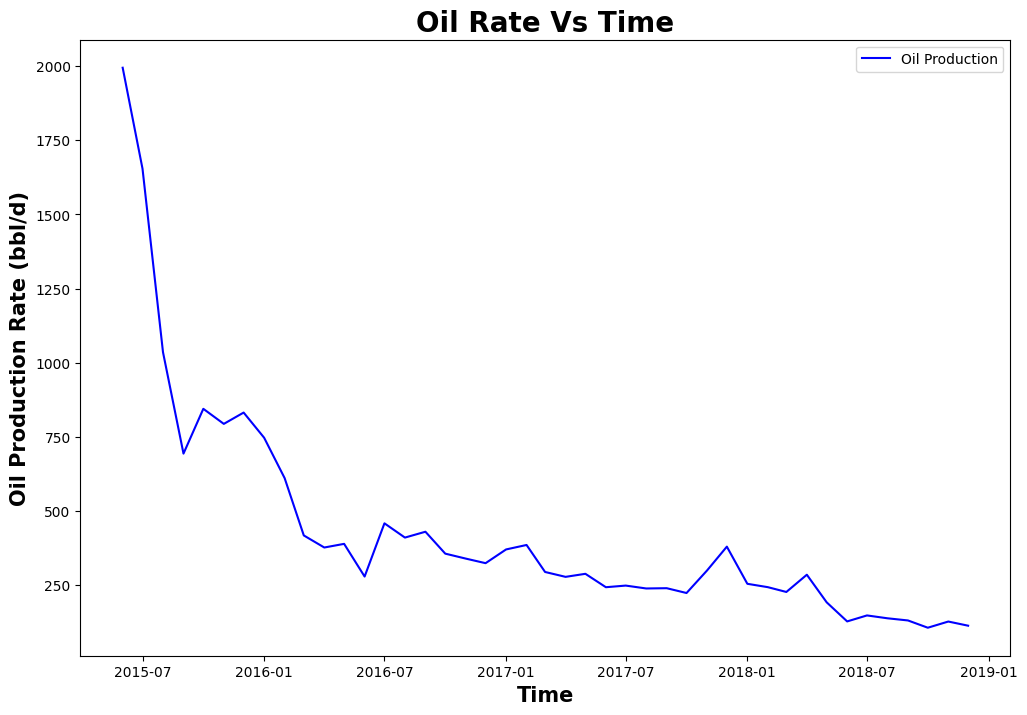

In [ ]:
#selecting the second API and plotting it
df_sel_2 = train_prod[train_prod['API_WELLNO'] == sel_well[1]]
df_sel_2["oil_rate"] = df_sel_2["Oil"] / df_sel_2["Days"]
df_sel_2['date_delta'] = (df_sel_2['ReportDate'] - df_sel_2['ReportDate'].min())/np.timedelta64(1,'D')
plot_production_rate(df_sel_2)

In [ ]:
df_sel_2 = df_sel_2[['date_delta', 'oil_rate']]
data_2 = df_sel_2.to_numpy()
# T is number of days of production - cumulative
# q is production rate
T_train_2, q_2 = data_2.T #.T transposes the array and unpacks the array
print(T_train_2)
print(q_2)

[   0.   30.   61.   92.  122.  153.  183.  214.  245.  274.  305.  335.
  366.  396.  427.  458.  488.  519.  549.  580.  611.  639.  670.  700.
  731.  761.  792.  823.  853.  884.  914.  945.  976. 1004. 1035. 1065.
 1096. 1126. 1157. 1188. 1218. 1249. 1279.]
[1994.9375     1654.4516129  1035.4         693.36666667  844.4516129
  793.62068966  831.80645161  746.90322581  610.75862069  417.38095238
  376.63333333  388.96774194  278.68965517  458.23076923  410.12903226
  429.86666667  355.96774194  339.26666667  323.80769231  370.125
  385.21428571  294.12903226  277.66666667  287.93548387  242.73333333
  248.22580645  238.48387097  239.4137931   223.16129032  299.1
  379.57142857  254.24137931  242.88461538  226.68965517  284.86206897
  191.76666667  127.36666667  147.5483871   137.90322581  130.6
  106.09677419  126.96551724  112.93548387]


In [ ]:
# Assumption - from the graph, we can assume qi to be the max oil production rate
qi_2 = df_sel_2['oil_rate'].max()
qi_2

1994.9375

In [ ]:
#defining the 3 DCA models using the decline_curve function that was defined earlier
exp_decline_2 = decline_curve("exponential", qi_2)
hyp_decline_2 = decline_curve("hyperbolic", qi_2)
har_decline_2 = decline_curve("harmonic", qi_2)

#fitting the decline curve models using the curve_fit, optimization method = Trust Region Reflective
popt_exp, pcov_exp = curve_fit(exp_decline_2, T_train_2, q_2, method="trf")
popt_hyp, pcov_hyp = curve_fit(hyp_decline_2, T_train_2, q_2, method="trf")
popt_har, pcov_har = curve_fit(har_decline_2, T_train_2, q_2, method="trf")

print("Exponential Decline:")
print("Optimal parameters:", popt_exp)
print("Estimated covariance:", pcov_exp)

print("\nHyperbolic Decline:")
print("Optimal parameters:", popt_hyp)
print("Estimated covariance:", pcov_hyp)

print("\nHarmonic Decline:")
print("Optimal parameters:", popt_har)
print("Estimated covariance:", pcov_har)


# L2 Norm (Euclidean Norm): It provides a quantitative measure of how well each model fits the observed data

print("L2 Norm of exponential decline: ", L2_norm(exp_decline_2(T_train_2, popt_exp[0]), q_2))
print("L2 Norm of hyperbolic decline decline: ",L2_norm(hyp_decline_2(T_train_2, popt_hyp[0], popt_hyp[1]), q_2))
print("L2 Norm of harmonic decline decline: ", L2_norm(har_decline_2(T_train_2, popt_har[0]), q_2))

Exponential Decline:
Optimal parameters: [1.]
Estimated covariance: [[0.]]

Hyperbolic Decline:
Optimal parameters: [0.01319601 1.28596688]
Estimated covariance: [[2.45513781e-06 1.67622820e-04]
 [1.67622820e-04 1.41730177e-02]]

Harmonic Decline:
Optimal parameters: [0.01025538]
Estimated covariance: [[2.65600939e-07]]
L2 Norm of exponential decline:  10167505.41462357
L2 Norm of hyperbolic decline decline:  309675.9298070103
L2 Norm of harmonic decline decline:  361356.90904455684


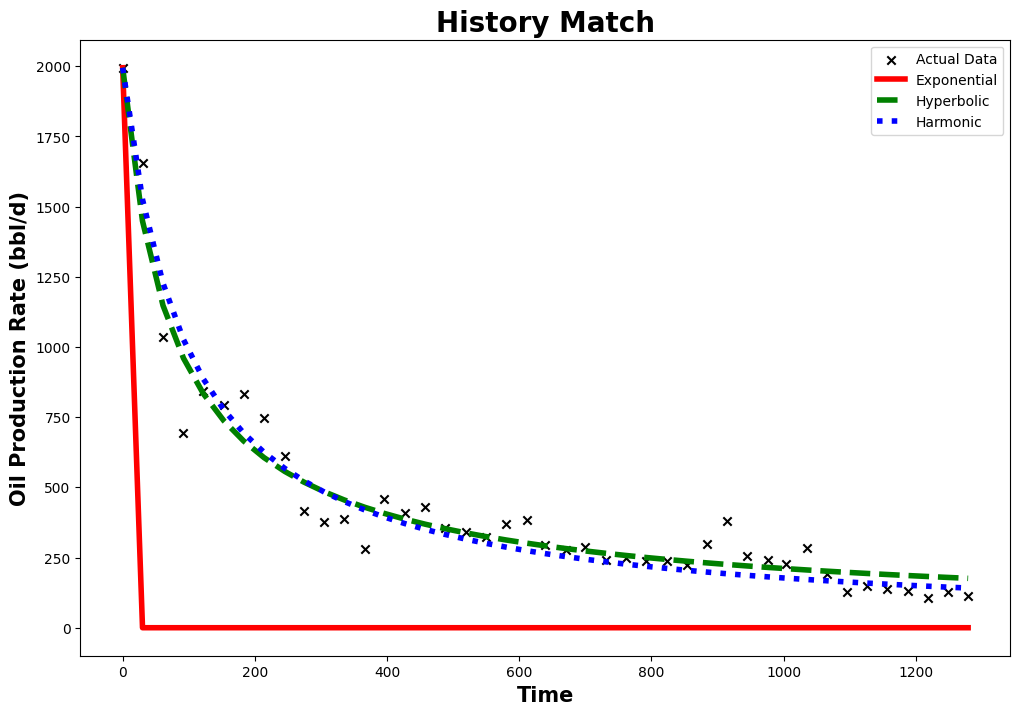

In [ ]:
# Predicting the oil rate using the fitted models
plt.figure(figsize=(12,8))
plt.scatter(T_train_2, q_2, color="black", label= "Actual Data", marker="x", alpha=1)
pred_exp = exp_decline_2(T_train_2, popt_exp[0])
pred_hyp = hyp_decline_2(T_train_2, popt_hyp[0], popt_hyp[1])
pred_har = har_decline_2(T_train_2, popt_har[0])
plt.plot(T_train_2, pred_exp, color="red", label="Exponential", linewidth = 4)
plt.plot(T_train_2, pred_hyp, color="green", label="Hyperbolic", linestyle="--", linewidth = 4)
plt.plot(T_train_2, pred_har, color="blue", label="Harmonic", linestyle = ':', linewidth = 4)
plt.title('History Match', fontweight='bold', fontsize = 20)
plt.xlabel('Time', fontweight='bold', fontsize = 15)
plt.ylabel('Oil Production Rate (bbl/d)', fontweight='bold', fontsize = 15)
plt.legend(loc='best')
plt.show()

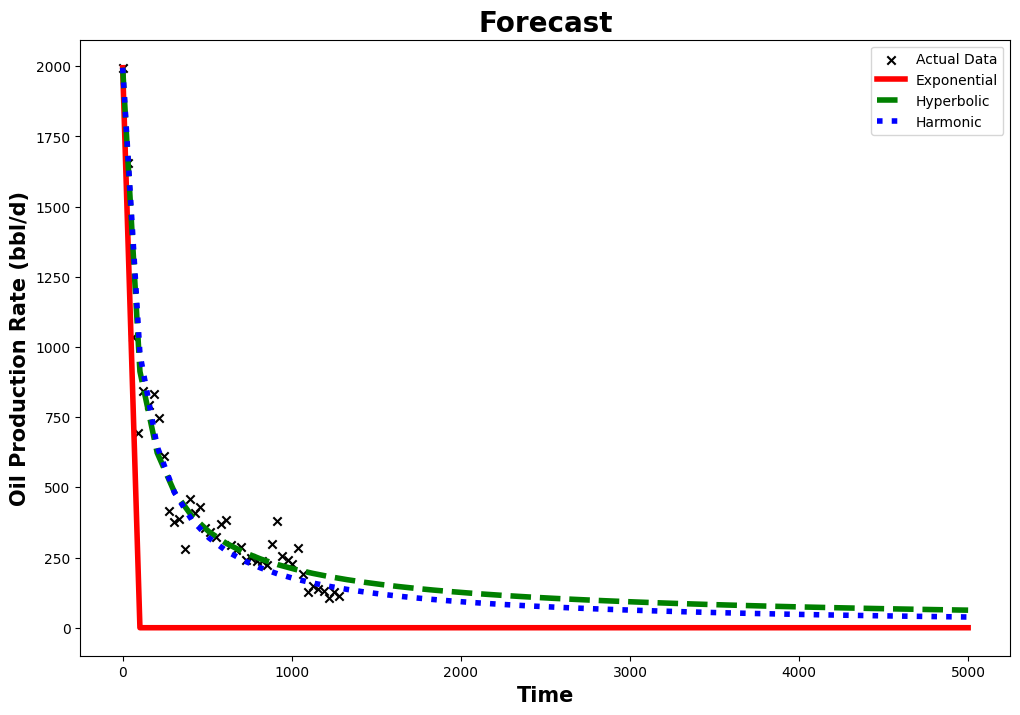

In [ ]:
# Forecasting to 5000 days
max_time_forecast = 5000
T_pred = np.linspace(min(T_train_2), max_time_forecast)

#Vizualizing the forecasting
plt.figure(figsize=(12,8))
plt.scatter(T_train_2, q_2, color="black", label="Actual Data", marker="x", alpha=1)
pred_exp = exp_decline_2(T_pred, popt_exp[0])
pred_hyp = hyp_decline_2(T_pred, popt_hyp[0], popt_hyp[1])
pred_har = har_decline_2(T_pred, popt_har[0])
plt.plot(T_pred, pred_exp, color="red", label="Exponential", linewidth = 4)
plt.plot(T_pred, pred_hyp, color="green", label="Hyperbolic", linestyle="--", linewidth = 4)
plt.plot(T_pred, pred_har, color="blue", label="Harmonic", linestyle = ':', linewidth = 4)
plt.title('Forecast', fontweight='bold', fontsize = 20)
plt.xlabel('Time', fontweight='bold', fontsize = 15)
plt.ylabel('Oil Production Rate (bbl/d)', fontweight='bold', fontsize = 15)
plt.legend(loc='best')
plt.show()

In [ ]:
# validation procedure: Validating the model with the test data

print('API:', sel_well[1])
df_sel_test = test_prod[test_prod['API_WELLNO'] == sel_well[1]]
df_sel_test["oil_rate"] = df_sel_test["Oil"] / df_sel_test["Days"]
df_sel_test['date_delta'] = (df_sel_test['ReportDate'] - df_sel_test['ReportDate'].min())  / np.timedelta64(1,'D')
print(df_sel_test)
df_sel_test = df_sel_test[['date_delta', 'oil_rate']]
data_test = df_sel_test.to_numpy()
# T is number of days of production - cumulative
# q is production rate
T_test, q_test = data_test.T

#T_test = np.concatenate(T_train, T)
print(T_test)
print(q_test)

API: 33025021780000
       ReportDate        API_WELLNO   FileNo  \
9237   2019-01-01 33025021780000.00 25736.00   
26666  2019-02-01 33025021780000.00 25736.00   
44161  2019-03-01 33025021780000.00 25736.00   
61730  2019-04-01 33025021780000.00 25736.00   
79421  2019-05-01 33025021780000.00 25736.00   
97225  2019-06-01 33025021780000.00 25736.00   
115149 2019-07-01 33025021780000.00 25736.00   
133202 2019-08-01 33025021780000.00 25736.00   
151359 2019-09-01 33025021780000.00 25736.00   
169616 2019-10-01 33025021780000.00 25736.00   
187967 2019-11-01 33025021780000.00 25736.00   

                                   Company              WellName Quarter  \
9237    ENERPLUS RESOURCES USA CORPORATION  SNOW  149-93-07A-12H    SENE   
26666   ENERPLUS RESOURCES USA CORPORATION  SNOW  149-93-07A-12H    SENE   
44161   ENERPLUS RESOURCES USA CORPORATION  SNOW  149-93-07A-12H    SENE   
61730   ENERPLUS RESOURCES USA CORPORATION  SNOW  149-93-07A-12H    SENE   
79421   ENERPLUS RESOUR

In [ ]:
#generates a sequence of date from 'start' with a frequency of Month Start.
#it creates a series of monthly dates
time_2 = pd.date_range(start='6/1/2015', periods= 54, freq='MS')
time_2

#aligning the time of the train data[-1: last date] with the test data
T_Test2 = T_train_2[-1] + T_test
len(T_Test2)

11

In [ ]:
#calculating the predicted prod rates for the train dataset and test dataset(with adjusted time)
pred_hyp =  hyp_decline_2(T_train_2, popt_hyp[0], popt_hyp[1])
pred_hyp2 = hyp_decline_2(T_Test2, popt_hyp[0], popt_hyp[1])
print(pred_hyp)
print(pred_hyp2)

[1994.9375     1448.62576796 1148.04118283  960.09163565  833.84616241
  737.35543199  665.22003716  605.68592895  557.07659257  518.96359759
  484.25039057  455.3220305   429.27541854  407.09626656  386.75357091
  368.59446648  352.77430862  337.96976613  324.92783225  312.60103436
  301.29356499  291.85138729  282.15313238  273.44126571  265.05961127
  257.48694419  250.16247665  243.29749669  237.05044018  230.96768984
  225.41034932  219.97896687  214.83776698  210.42390577  205.77211495
  201.48820459  197.26992985  193.3750533   189.5303175   185.85597128
  182.4515345   179.07983009  175.94945389]
[175.94945389 172.84316894 170.14306192 167.26370156 164.5810902
 161.91023261 159.41799886 156.93297715 154.53476677 152.29219405
 150.05154914]


In [ ]:
# forecast
#combines the actual production rates for comparison with the forecast.
q_orig_2 = np.append(q_2, q_test)

#combines the predicted production rates for the training data (pred_hyp)
#and the test data (pred_hyp2) into a single array called forecast.
forecast_2 = np.concatenate([pred_hyp, pred_hyp2])

print(len(time_2))
print(len(q_orig_2),len(forecast_2))

54
54 54


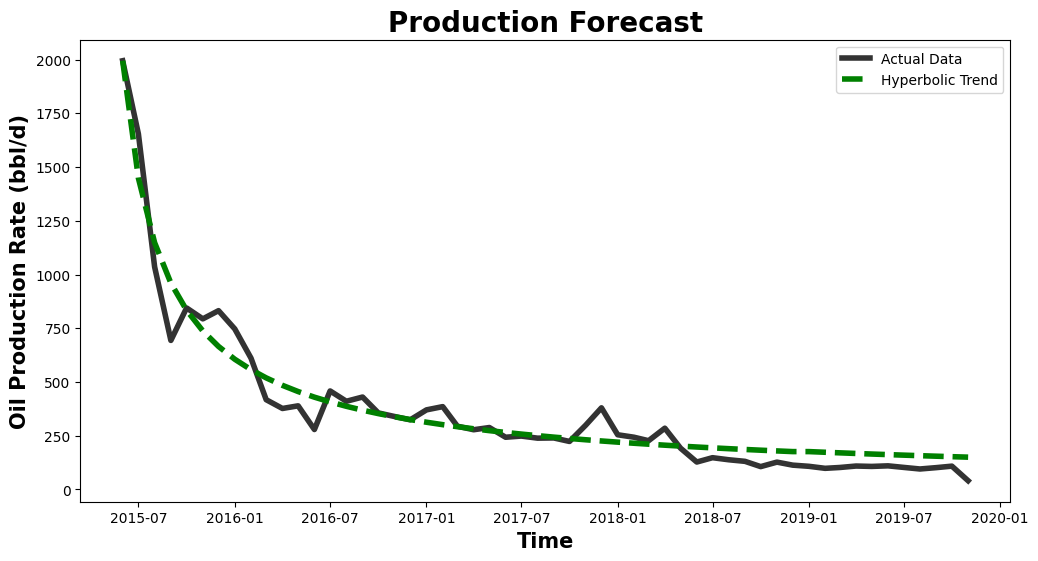

In [ ]:
# hyperbolic forecast - plot
plt.figure(figsize=(12,6))
plt.plot(time_2, q_orig_2, color="black", alpha = 0.8, label='Actual Data', linewidth = 4)
plt.plot(time_2, forecast_2, color="green", label="Hyperbolic Trend", linewidth = 4, linestyle="--")
plt.title('Production Forecast', fontweight='bold', fontsize = 20)
plt.xlabel('Time', fontweight='bold', fontsize = 15)
plt.ylabel('Oil Production Rate (bbl/d)', fontweight='bold', fontsize = 15)
plt.legend(loc='best')
plt.show()

In [ ]:
from sklearn.metrics import mean_squared_error

rmse_2 = sqrt(mean_squared_error(q_orig_2, forecast_2))
print("RMSE - Hyperbolic Method:", rmse_2)

RMSE - Hyperbolic Method: 81.41922170670097
